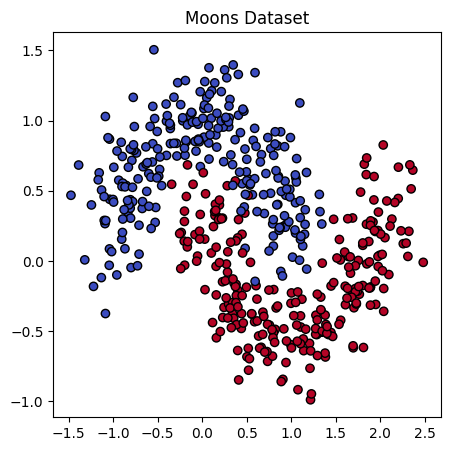

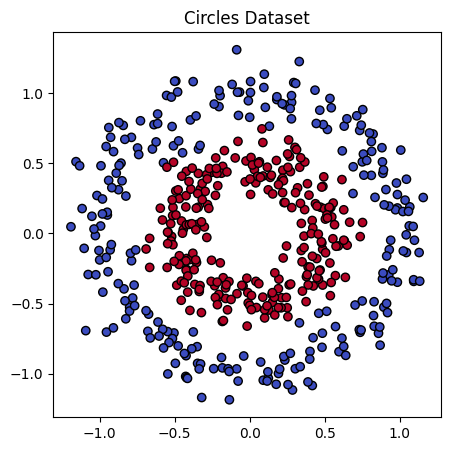

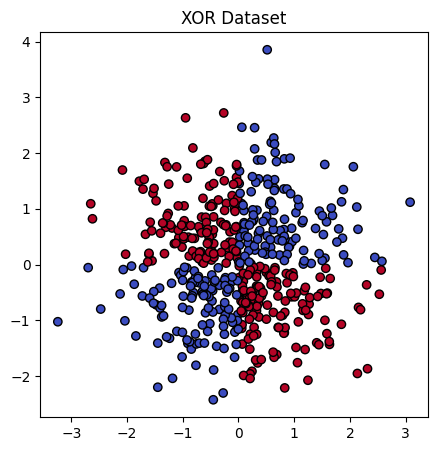


================ Multi-Class SVM ================

One-vs-One Accuracy: 1.0
One-vs-Rest Accuracy: 1.0

================ Experiment Completed ================



In [1]:
# ==========================================================
# EXPERIMENT 8
# SVM WITH NON-LINEAR KERNELS
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# ==========================================================
# PART A — DATA GENERATION
# ==========================================================

# 1) Moons Dataset
X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=42)

# 2) Circles Dataset
X_circles, y_circles = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)

# 3) XOR Dataset
np.random.seed(42)
X_xor = np.random.randn(500, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0)
y_xor = np.where(y_xor, 1, 0)

# ==========================================================
# FUNCTION TO PLOT DATASET
# ==========================================================

def plot_dataset(X, y, title):
    plt.figure(figsize=(5,5))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.show()

plot_dataset(X_moons, y_moons, "Moons Dataset")
plot_dataset(X_circles, y_circles, "Circles Dataset")
plot_dataset(X_xor, y_xor, "XOR Dataset")

# ==========================================================
# FUNCTION TO PLOT DECISION BOUNDARY
# ==========================================================

def plot_decision_boundary(model, X, y, title):

    plt.figure(figsize=(6,5))

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')

    # Highlight support vectors
    plt.scatter(
        model.support_vectors_[:,0],
        model.support_vectors_[:,1],
        s=120,
        facecolors='none',
        edgecolors='black',
        label='Support Vectors'
    )


    plt.title(title)
    plt.legend()
    plt.show()



# ==========================================================
# BONUS — MULTI-CLASS CLASSIFICATION
# ==========================================================

print("\n================ Multi-Class SVM ================\n")

X_multi, y_multi = make_blobs(n_samples=500, centers=3, random_state=42)

model_ovo = svm.SVC(kernel='rbf', decision_function_shape='ovo')
model_ovr = svm.SVC(kernel='rbf', decision_function_shape='ovr')

model_ovo.fit(X_multi, y_multi)
model_ovr.fit(X_multi, y_multi)

print("One-vs-One Accuracy:", model_ovo.score(X_multi, y_multi))
print("One-vs-Rest Accuracy:", model_ovr.score(X_multi, y_multi))

print("\n================ Experiment Completed ================\n")